In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import scipy.stats as stats

In [2]:
# create dataset

np.random.seed (42)        # random number wont be generated

data = { 

    'product_id' : range(1,21),
    'producct_name' : [f'product{i}' for i in range(1,21)],
    'category': np.random.choice(['Electronic', 'cloting', 'Home', 'Sports'], 20),
    'units_sold' :np.random.poisson(lam = 20, size = 20),
    'Sales_data' : pd.date_range (start = '2023-01-01', periods = 20, freq = 'D')
}
       


sales_data = pd.DataFrame(data)

print('sales Data:')
print(sales_data)

 


sales Data:
    product_id producct_name    category  units_sold Sales_data
0            1      product1        Home          25 2023-01-01
1            2      product2      Sports          15 2023-01-02
2            3      product3  Electronic          17 2023-01-03
3            4      product4        Home          19 2023-01-04
4            5      product5        Home          21 2023-01-05
5            6      product6      Sports          17 2023-01-06
6            7      product7  Electronic          19 2023-01-07
7            8      product8  Electronic          16 2023-01-08
8            9      product9        Home          21 2023-01-09
9           10     product10     cloting          21 2023-01-10
10          11     product11        Home          17 2023-01-11
11          12     product12        Home          22 2023-01-12
12          13     product13        Home          14 2023-01-13
13          14     product14        Home          17 2023-01-14
14          15     product15

In [3]:
# Save the dataframe into CSV file

sales_data.to_csv('sales_data.csv', index = False)


In [4]:
import os
os.getcwd()

'C:\\Users\\ybali'

In [34]:
# Descriptive stats

descriptive_stats = sales_data['units_sold'].describe()

print('\n Descriptive stats for units sold')
print(descriptive_stats)

mean_sales = sales_data['units_sold'].mean()
median_sales = sales_data['units_sold'].median()
mode_sales = sales_data['units_sold'].mode()[0]
variance_sales = sales_data['units_sold'].var()
std_deviation_sales = sales_data['units_sold'].std()

category_stats = sales_data.groupby('category')['units_sold'].agg(['sum', 'mean', 'std']).reset_index()
category_stats.columns = ['Category', 'Total Units Sold', 'Average Units Sold', 'Std Dev of Units Sold']

print('\n stastistical Analysis:')
print(f'Mean units sold: {mean_sales}')
print(f'Median units sold: {median_sales}')
print(f'Mode units sold: {mode_sales}')
print(f'variance units sold: {variance_sales}')
print(f'Standard devation units sold: {std_deviation_sales}')

print('\ncategory Statistics')

print(category_stats)






 Descriptive stats for units sold
count    20.000000
mean     18.800000
std       3.302312
min      13.000000
25%      17.000000
50%      18.500000
75%      21.000000
max      25.000000
Name: units_sold, dtype: float64

 stastistical Analysis:
Mean units sold: 18.8
Median units sold: 18.5
Mode units sold: 17
variance units sold: 10.90526315789474
Standard devation units sold: 3.3023117899275864

category Statistics
     Category  Total Units Sold  Average Units Sold  Std Dev of Units Sold
0  Electronic                73           18.250000               2.217356
1        Home               181           20.111111               3.723051
2      Sports               101           16.833333               2.714160
3     cloting                21           21.000000                    NaN


In [35]:
# Inferential statstics

confidence_level = 0.95

freedom_sales = len(sales_data['units_sold']) - 1
sample_mean = mean_sales
sample_standard_error = std_deviation_sales / np.sqrt(len(sales_data['units_sold']))


# t_score

t_score = stats.t.ppf((1 + confidence_level) /2, freedom_sales)
margin_of_error = t_score * sample_standard_error

confidence_level = (sample_mean - margin_of_error, sample_mean + margin_of_error)
print('confidence interval for mean')
print(confidence_level)

  
                                                          

confidence interval for mean
(np.float64(17.254470507823573), np.float64(20.34552949217643))


In [36]:
t_statistic, p_value = stats.ttest_1samp(sales_data['units_sold'], 20)

print('\n Hypothesis Testing')
print(f'T-statistic: {t_statistic}, p_value: {p_value}')

if p_value < 0.05:
    print('Rejecct')
else:
    print('Fail')


 Hypothesis Testing
T-statistic: -1.6250928099424466, p_value: 0.12061572226781002
Fail


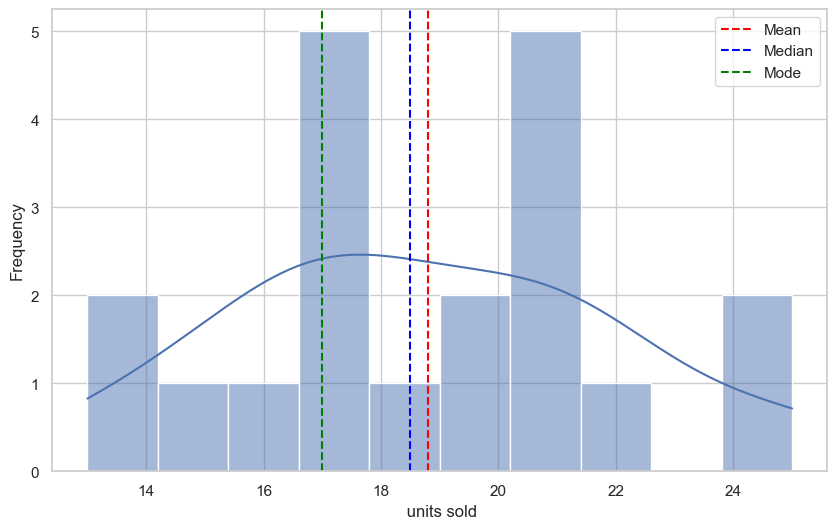

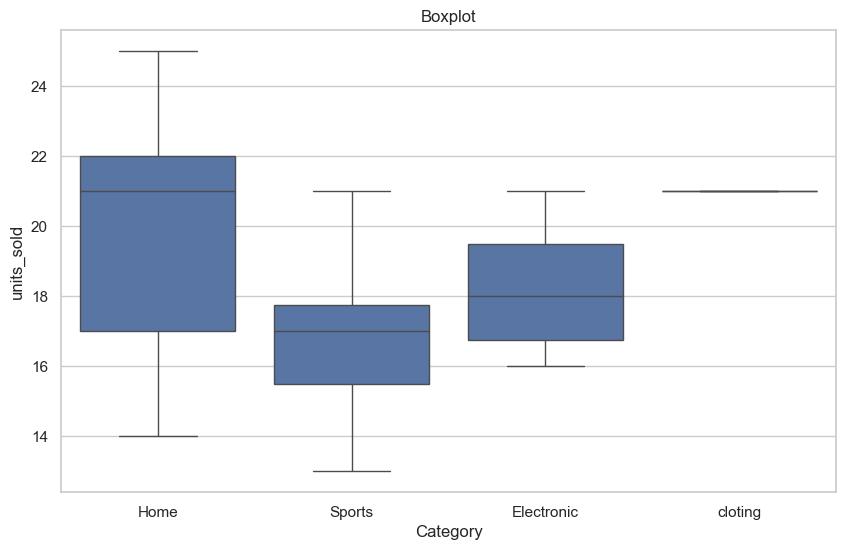

ValueError: Could not interpret value `category` for `x`. An entry with this name does not appear in `data`.

<Figure size 1000x600 with 0 Axes>

In [40]:
# visualization


sns.set(style = 'whitegrid')

# plot 
plt.figure(figsize=(10,6))
sns.histplot(sales_data['units_sold'], bins = 10, kde = True)
plt.xlabel(' units sold')
plt.ylabel('Frequency')
plt.axvline(mean_sales, color = 'red' , linestyle = '--' , label = 'Mean')
plt.axvline(median_sales, color = 'blue' , linestyle = '--' , label = 'Median')
plt.axvline(mode_sales, color = 'green', linestyle = '--' , label = 'Mode')
plt.legend()
plt.show()


#Boxplot
plt.figure(figsize=(10,6))
sns.boxplot(x = 'category' , y = 'units_sold', data = sales_data)
plt.title('Boxplot')
plt.xlabel('Category')
plt.ylabel('units_sold')
plt.show()

#Barplot

plt.figure(figsize=(10,6))
sns.barplot(x = 'Category' , y = 'Total units slod', data = category_stats)
plt.title('Barplot')
plt.xlabel('category')
plt.ylabel('units_sold')
plt.show()










